
# Graph Fusion GNN Experiment

This notebook trains a **Graph Neural Network (GraphFusionNet)** using static and dynamic data features and evaluates its performance using t-SNE visualization.

---
### **Pipeline Overview**
1. Configuration  
2. Load dataset  
3. Label nodes  
4. Extract feature groups  
5. Normalize features  
6. Convert to tensors  
7. Create masks (train/val/test)  
8. Train model  
9. Evaluate and visualize embeddings


**GraphFusionNet-1 Architecture:**  
GraphFusionNet-1 is a dual-branch graph neural network designed to fuse node features from two distinct graphs sharing the same topology. Each input (`x1`, `x2`) passes through its own graph convolution layer (`gcn1_1`, `gcn1_2`) to produce hidden representations (`h1`, `h2`). These are combined using a learnable fusion weight α via a weighted sum \( h = αh_1 + (1 - α)h_2 \). The fused embedding `h` then passes through another pair of graph convolution layers (`gcn2_1`, `gcn2_2`), followed by a second fusion stage using the same α parameter to yield the final output. This design enables adaptive feature blending from multiple graph sources, enhancing joint representation learning.


**GraphFusionNet-1 Summary:**

- Designed for fusing static and dynamic graph data.  
- Inputs: node features `x1` (static), `x2` (dynamic), and shared `edge_index`.  
- Two parallel GCN layers extract features from both data sources. 
- Each branch has its own graph convolution layer (`gcn1_1` and `gcn1_2`).  
- Outputs from both branches (`h1`, `h2`) are combined using a learnable weight **α**.  
- Fusion equation:
  \( h = αh_1 + (1 - α)h_2 \).  
- A second GCN layer refines the fused representation into final output.  
- Returns either the fused embedding (`h`) or final output (`out`). 


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *

c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [ ]:
seed = 42
set_seed(seed)

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'StaticDynamicGNN_adv_3'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "3_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "M5"     

output_folder = f"results/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:49: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

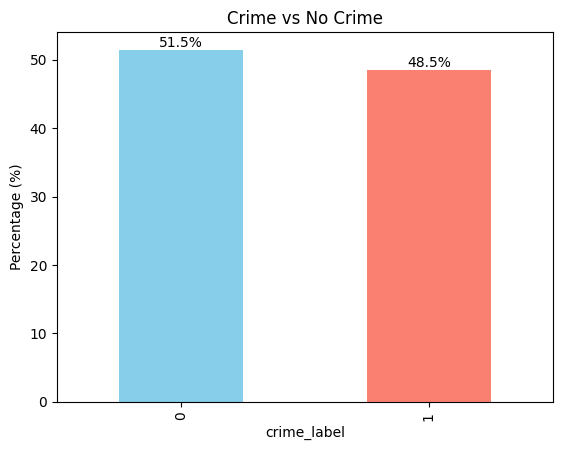

In [6]:
plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [8]:
dynamic_dt

,2006.01,2006.02,2006.03,2006.04,2006.05,2006.06,2006.07,2006.08,2006.09,2006.10,...,2017.03,2017.04,2017.05,2017.06,2017.07,2017.08,2017.09,2017.10,2017.11,2017.12
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
2,0,1,0,1,1,0,0,0,0,1,...,0,1,0,0,0,1,0,0,1,0
3,0,0,0,1,0,0,0,2,0,0,...,2,2,1,0,0,2,0,1,5,3
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14636,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14637,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
14638,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Normalize features


In [9]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

global_min = dynamic_dt_smooth_log.min().min()
global_max = dynamic_dt_smooth_log.max().max()
dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

# global_min = dynamic_dt.min().min()
# global_max = dynamic_dt.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt - global_min) / (global_max - global_min))

scaler = MinMaxScaler()

# dynamic_dt_norm = pd.DataFrame(scaler.fit_transform(dynamic_dt))
static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

In [10]:
dynamic_dt_norm

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
0,0.181908,0.101764,0.068631,0.050455,0.039000,0.031149,0.025458,0.021163,0.017823,0.050679,...,0.130997,0.120476,0.110633,0.101447,0.092895,0.084953,0.077593,0.070788,0.064509,0.058727
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.046022,0.038504,0.067939,0.058584,...,0.082829,0.075628,0.068973,0.062837,0.057188,0.051999,0.068292,0.062209,0.056611,0.051469
2,0.000000,0.110974,0.075256,0.110974,0.130145,0.107278,0.089832,0.076123,0.065109,0.086776,...,0.073875,0.086912,0.079407,0.072464,0.066054,0.080229,0.073224,0.066755,0.080827,0.073776
3,0.000000,0.000000,0.000000,0.066987,0.052138,0.041847,0.034326,0.100458,0.086466,0.074905,...,0.216304,0.224462,0.220504,0.205147,0.190513,0.202105,0.187618,0.187053,0.233624,0.249961
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.021957,0.019842,0.017924,0.016186,0.014611,0.013186,0.011897,0.010731,0.009678,0.008726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14637,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14638,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Convert to tensors & Graph Data Object


In [11]:
dynamic_tensor = torch.tensor(dynamic_dt_norm.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt_norm.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

crime_labels = df_nodes_label[crime_label_col]
crime_label_tensor = torch.tensor(crime_labels.values, dtype=torch.long)

data_dynamic = Data(x=dynamic_tensor, edge_index=edge_index, y=crime_label_tensor)
data_static = Data(x=static_tensor, edge_index=edge_index, y=crime_label_tensor)
data_mask = Data(x=torch.empty((num_nodes, 0)), edge_index=torch.empty((2, 0), dtype=torch.long))

In [12]:
crime_labels = df_nodes_label[crime_label_col].values.reshape(-1)  # ensure 1D
crime_label_tensor = torch.tensor(crime_labels, dtype=torch.long)

In [13]:
crime_label_tensor

tensor([1, 1, 1,  ..., 0, 0, 0])

# Train / Validation / Test split

In [14]:
train_mask, val_mask, test_mask = stratified_graph_split(crime_label_tensor, train_ratio=0.6, val_ratio=0.2, random_state= seed)

In [15]:
# Attach to data object
data_mask.train_mask = train_mask
data_mask.val_mask = val_mask
data_mask.test_mask = test_mask

In [16]:
print("Stratified split done:")
print(f"Train: {train_mask.sum().item()} | Val: {val_mask.sum().item()} | Test: {test_mask.sum().item()}")
print("Label ratio in each split:")
print(pd.Series(crime_label_tensor[train_mask]).value_counts(normalize=True))
print(pd.Series(crime_label_tensor[val_mask]).value_counts(normalize=True))
print(pd.Series(crime_label_tensor[test_mask]).value_counts(normalize=True))

Stratified split done:
Train: 8784 | Val: 2928 | Test: 2928
Label ratio in each split:
0    0.514572
1    0.485428
Name: proportion, dtype: float64
0    0.514686
1    0.485314
Name: proportion, dtype: float64
0    0.514686
1    0.485314
Name: proportion, dtype: float64


# Model initialization


In [17]:
num_features_static = data_static.x.shape[1]
num_features_dynamic = data_dynamic.x.shape[1]
num_classes = 2

# model = StaticDynamicGNN_nonato(in_static=num_features_static,
#                 in_dynamic=num_features_dynamic,
#                 # hidden_dim=64,
#                 out_channels=2) 
# model = StaticDynamicGNN_hidden(in_static=num_features_static,
#                 in_dynamic=num_features_dynamic,
#                 hidden_dim=32,
#                 out_channels=2) 
model = StaticDynamicGNN_adv_3(in_static=num_features_static,
                in_dynamic=num_features_dynamic,
                hidden_dim=32,
                out_channels=2) 

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Train model


In [18]:
train_losses, val_accs, test_accs, alpha_values = train_loop_fusion_scra(model, optimizer, data_static, data_dynamic, data_mask, epochs=200, method_model=f"{model_used}_{type_graph_conv}_{architecture}")


Epoch 020 | Loss: 0.2175 | Train: 0.817 | Val: 0.811 | Test: 0.815 | Alpha_stat: 0.270 | Alpha_dyn: 0.278
Epoch 040 | Loss: 0.0753 | Train: 0.976 | Val: 0.974 | Test: 0.975 | Alpha_stat: 0.310 | Alpha_dyn: 0.353
Epoch 060 | Loss: 0.0426 | Train: 0.994 | Val: 0.991 | Test: 0.990 | Alpha_stat: 0.300 | Alpha_dyn: 0.338
Epoch 080 | Loss: 0.0261 | Train: 0.997 | Val: 0.995 | Test: 0.997 | Alpha_stat: 0.284 | Alpha_dyn: 0.291
Epoch 100 | Loss: 0.0288 | Train: 0.953 | Val: 0.950 | Test: 0.956 | Alpha_stat: 0.272 | Alpha_dyn: 0.257
Epoch 120 | Loss: 0.0155 | Train: 0.986 | Val: 0.981 | Test: 0.982 | Alpha_stat: 0.261 | Alpha_dyn: 0.242
Epoch 140 | Loss: 0.0103 | Train: 0.998 | Val: 0.994 | Test: 0.994 | Alpha_stat: 0.252 | Alpha_dyn: 0.212
Epoch 160 | Loss: 0.0339 | Train: 0.854 | Val: 0.850 | Test: 0.838 | Alpha_stat: 0.244 | Alpha_dyn: 0.208
Epoch 180 | Loss: 0.0240 | Train: 0.998 | Val: 0.997 | Test: 0.996 | Alpha_stat: 0.264 | Alpha_dyn: 0.284
Epoch 200 | Loss: 0.0123 | Train: 1.000 | Val:

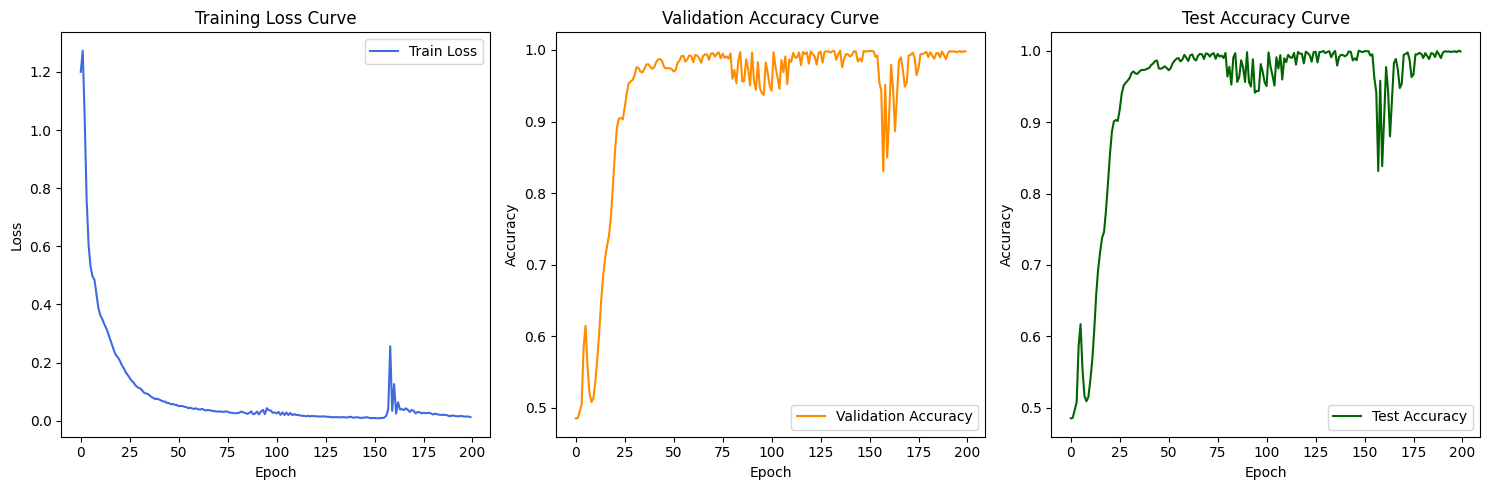

In [19]:
plot_train_val_curves(train_losses, val_accs, test_accs, filename=f'train_val_test_plot_{model_used}_{type_graph_conv}_{architecture}', output_path= output_folder)

# Evaluate model


In [20]:
train_acc, val_acc, test_acc, _ = evaluate_fusion_scra(model, data_static, data_dynamic, data_mask)
print(f"Final Results:\\nTrain Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f} | Test Acc: {test_acc:.3f}")


Final Results:\nTrain Acc: 1.000 | Val Acc: 0.998 | Test Acc: 0.999


In [21]:
model_used

'M5'

In [23]:
results = {
    "Model": [f"{model_used}_{type_graph_conv}_{architecture}"],
    "Train_Acc": [train_acc],
    "Val_Acc": [val_acc],
    "Test_Acc": [test_acc]
}
# Convert to DataFrame
results_df = pd.DataFrame(results)

# Save as CSV (append if file already exists)
results_path = os.path.join(output_folder, "results_summary.csv")
if os.path.exists(results_path):
    old = pd.read_csv(results_path)
    results_df = pd.concat([old, results_df], ignore_index=True)

results_df.to_csv(results_path, index=False)

# Extract embeddings


In [24]:
model.eval()
with torch.no_grad():
    embeddings, _ = model(data_static.x, data_dynamic.x, data_dynamic.edge_index, return_embedding=True)

print(f"Node Embeddings shape: {embeddings.shape}")

Node Embeddings shape: torch.Size([14640, 32])


In [25]:
alpha_values

[{'static_dataset': 0.2659358084201813,
  'dynamic_dataset': 0.04981704428792,
  'grad_static': 0.01111619733273983,
  'grad_dynamic': 0.004405418410897255,
  'grad_ratio_static': 0.7161748077386023,
  'grad_ratio_dynamic': 0.2838245479989882},
 {'static_dataset': 0.2601693570613861,
  'dynamic_dataset': 0.07111293077468872,
  'grad_static': 0.009645960293710232,
  'grad_dynamic': 0.0014249171363189816,
  'grad_ratio_static': 0.8712906128506067,
  'grad_ratio_dynamic': 0.12870848387943745},
 {'static_dataset': 0.2578701078891754,
  'dynamic_dataset': 0.08859506249427795,
  'grad_static': 0.006286018993705511,
  'grad_dynamic': 0.0009321050019934773,
  'grad_ratio_static': 0.8708648242677555,
  'grad_ratio_dynamic': 0.12913379033263767},
 {'static_dataset': 0.2560666799545288,
  'dynamic_dataset': 0.10317868739366531,
  'grad_static': 0.0055236294865608215,
  'grad_dynamic': 0.0007469274569302797,
  'grad_ratio_static': 0.8808819898325769,
  'grad_ratio_dynamic': 0.11911641541529135},
 

# Feature Contribution

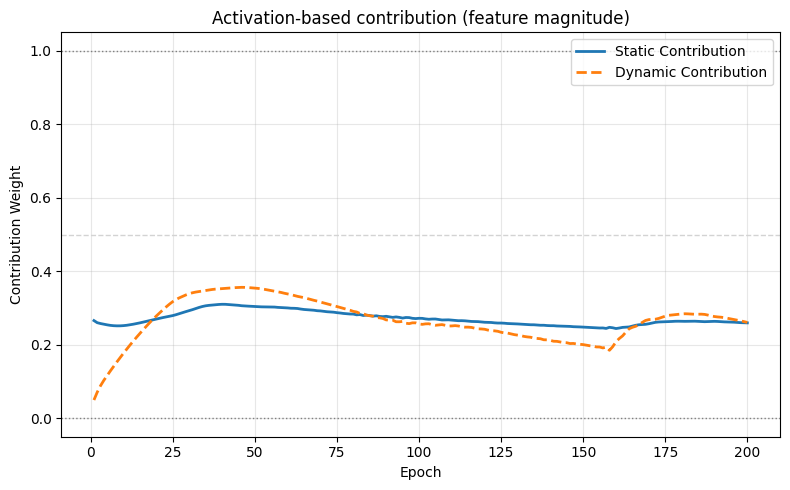

In [26]:
plot_features_contribution(alpha_values=alpha_values, title = "Activation-based contribution (feature magnitude)", filename=f"plot_feature_contribution_{model_used}_{type_graph_conv}_{architecture}", output_path=output_folder)

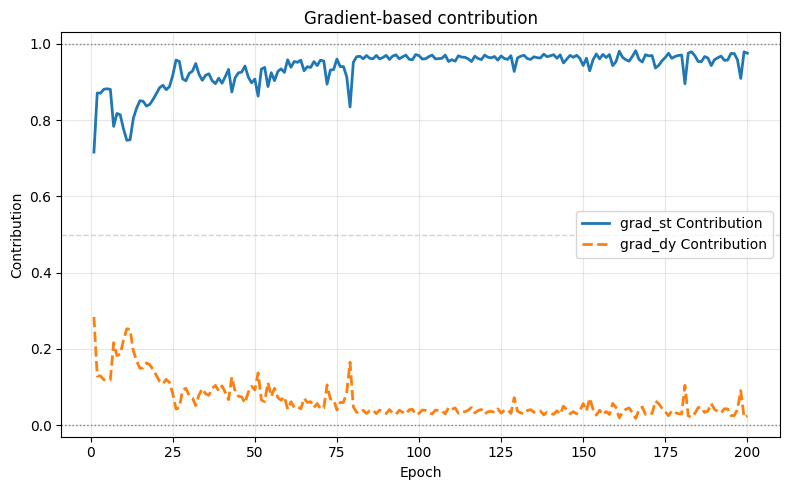

In [27]:
plot_gradient_contribution(alpha_values=alpha_values, title = "Gradient-based contribution", filename=f"plot_gradient_contribution_{model_used}_{type_graph_conv}_{architecture}", output_path=output_folder)

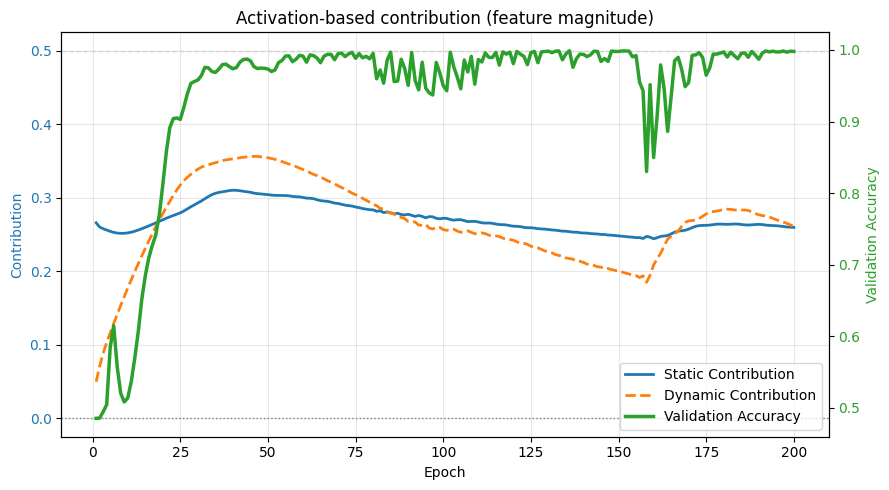

In [28]:
plot_feature_contr_validation_scr(alpha_values, val_accs, title = "Activation-based contribution (feature magnitude)", filename = f"feature_contrib_val_scr_{model_used}_{type_graph_conv}_{architecture}", output_path = output_folder)

# t-SNE visualization

In [29]:
tsne = TSNE(n_components=2, random_state=seed)
emb_2d = tsne.fit_transform(embeddings.cpu())

tsne_result = pd.DataFrame(emb_2d)
tsne_result.to_csv(f"{output_folder}/tsne_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)

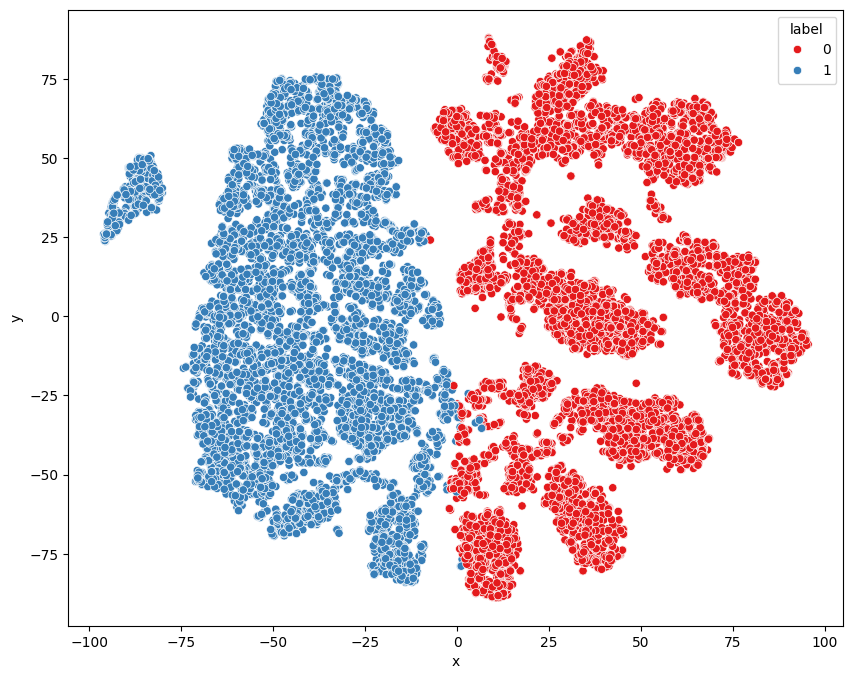

In [30]:
plot_embedding(emb_2d, crime_label_tensor, filename= f'embedding_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)

In [31]:
model.eval()
with torch.no_grad():
    out_model, _ = model(data_static.x, data_dynamic.x, data_dynamic.edge_index, return_embedding=False)

print(f"Node Embeddings shape: {out_model.shape}")

Node Embeddings shape: torch.Size([14640, 2])


In [32]:
out_model


tensor([[-29.0184,  24.0814],
        [-26.2979,  22.2367],
        [-49.3604,  40.4895],
        ...,
        [ 17.4499, -13.1844],
        [ 17.7405, -12.1406],
        [ 16.8090, -14.6220]])

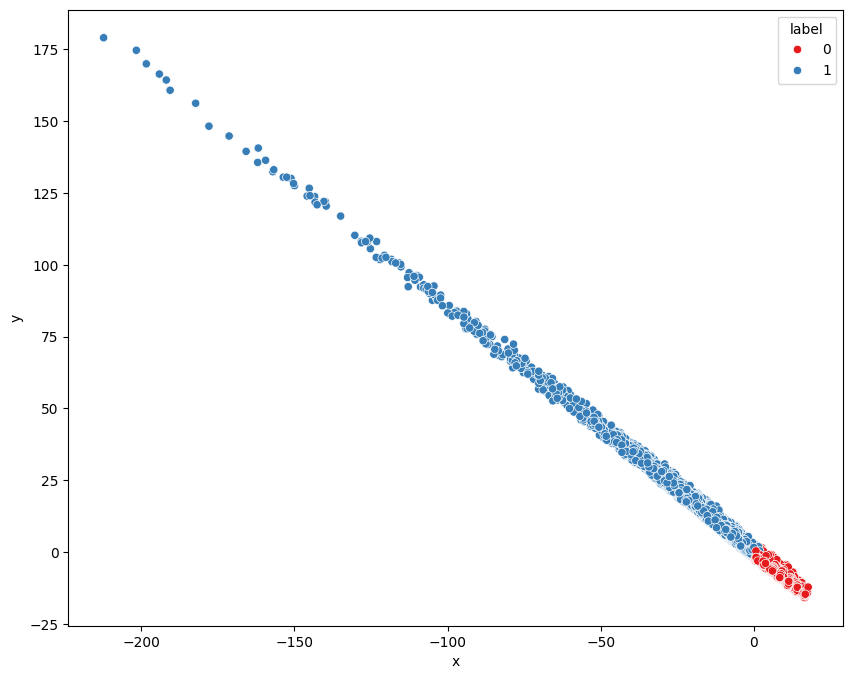

In [33]:
plot_embedding(out_model, crime_label_tensor, filename= f'model_output_2D_embedding_{model_used}_{type_graph_conv}_{architecture}', output_path = output_folder)

In [34]:
# Convert tensor to NumPy
out_array = out_model.detach().cpu().numpy()

In [35]:
pd.DataFrame(out_array).to_csv(f"{output_folder}/model_output_{model_used}_{type_graph_conv}_{architecture}.csv", index=False)